## **Analyzing Spotify Listening Data!!**

**Establishing path and file name & Imports**

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
FILE_PATTERN = "Streaming_History_Audio_*.json"
DATA_FOLDER = Path("my_spotify_data") / "Spotify Extended Streaming History"

candidate_base_dirs = [Path.cwd(), Path.cwd().parent]
BASE_DIR = next((base for base in candidate_base_dirs if (base / DATA_FOLDER).exists()), None)

if BASE_DIR is None:
    raise FileNotFoundError(f"Could not find '{DATA_FOLDER}' from {candidate_base_dirs}")

PATH = BASE_DIR / DATA_FOLDER
files = sorted(PATH.glob(FILE_PATTERN))

print(f"Using data folder: {PATH}")
print(f"Found {len(files)} file(s).")

Using data folder: c:\Users\bhana\Downloads\music-insights-llm\my_spotify_data\Spotify Extended Streaming History
Found 13 file(s).


**creating df**

In [6]:
if not files:
    raise FileNotFoundError(f"No JSON files found in: {PATH}")

df = pd.concat([pd.read_json(file) for file in files], ignore_index=True)

# Drop columns that aren't useful for analysis
drop_cols = [c for c in ["ip_addr_decrypted", "ip_addr", "offline_timestamp"] if c in df.columns] #dropping columns that aren't useful/privacy concerns
df = df.drop(columns=drop_cols)


In [4]:
print(df.shape)

(148725, 22)


In [7]:
df

,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,...,audiobook_title,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,incognito_mode
0,2017-07-19T22:30:06Z,"iOS 10.3.2 (iPad5,3)",1857,US,HUMBLE.,Kendrick Lamar,DAMN.,spotify:track:7KXjTSCq5nL1LoYtL7XAwS,None,None,...,NaN,NaN,NaN,NaN,clickrow,unexpected-exit-while-paused,True,False,False,False
1,2017-07-19T22:32:28Z,"iOS 10.3.2 (iPad5,3)",20038,US,True Feeling,Galantis,True Feeling,spotify:track:6SRnVRobwLtovI4JEWejDv,None,None,...,NaN,NaN,NaN,NaN,clickrow,endplay,False,False,False,False
2,2017-07-19T22:32:47Z,"iOS 10.3.2 (iPad5,3)",2197,US,Sit Next to Me,Foster The People,Sit Next to Me,spotify:track:14aqr8yZODpQyuqhSxLMTV,None,None,...,NaN,NaN,NaN,NaN,clickrow,backbtn,False,False,False,False
3,2017-07-19T22:32:47Z,"iOS 10.3.2 (iPad5,3)",725,US,A Lie,French Montana,Jungle Rules,spotify:track:1vVNlXi8gf8tZ7OhnEs4VE,None,None,...,NaN,NaN,NaN,NaN,backbtn,fwdbtn,False,False,False,False
4,2017-07-19T22:32:51Z,"iOS 10.3.2 (iPad5,3)",3648,US,Sit Next to Me,Foster The People,Sit Next to Me,spotify:track:14aqr8yZODpQyuqhSxLMTV,None,None,...,NaN,NaN,NaN,NaN,fwdbtn,backbtn,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148720,2026-04-11T17:00:03Z,ios,38591,US,I Think I Saw,Chanel Beads,Your Day Will Come,spotify:track:0vN0RFz15RkoonNLQPLgW1,NaN,NaN,...,NaN,NaN,NaN,NaN,trackdone,fwdbtn,True,True,False,False
148721,2026-04-11T17:00:05Z,ios,1741,US,idea 1,Kelela,idea 1,spotify:track:3ZTKg748vW7Zrll3wzwjJy,NaN,NaN,...,NaN,NaN,NaN,NaN,fwdbtn,fwdbtn,True,True,False,False
148722,2026-04-11T17:00:41Z,ios,36664,US,If Tomorrow Was Today,mach5,If Tomorrow Was Today,spotify:track:4YedZAtNzr0l0afAkzxFc0,NaN,NaN,...,NaN,NaN,NaN,NaN,fwdbtn,endplay,True,True,False,False
148723,2026-04-11T17:02:11Z,ios,91200,US,angel's pulse,User116,EAT DRINK SLEEP,spotify:track:2kB8GTRSN4AiLyKCOsjw5m,NaN,NaN,...,NaN,NaN,NaN,NaN,clickrow,trackdone,True,False,False,False


**prior analysis**

looking into dataframe

In [8]:
print(df.dtypes)

ts                                    object
platform                              object
ms_played                              int64
conn_country                          object
master_metadata_track_name            object
master_metadata_album_artist_name     object
master_metadata_album_album_name      object
spotify_track_uri                     object
episode_name                          object
episode_show_name                     object
spotify_episode_uri                   object
audiobook_title                      float64
audiobook_uri                        float64
audiobook_chapter_uri                float64
audiobook_chapter_title              float64
reason_start                          object
reason_end                            object
shuffle                                 bool
skipped                                 bool
offline                                 bool
incognito_mode                          bool
dtype: object


In [9]:
print(df["skipped"].value_counts())

skipped
False    116459
True      32266
Name: count, dtype: int64


In [10]:
print(df["offline"].value_counts())

offline
False    147697
True       1028
Name: count, dtype: int64


In [11]:
#countries i've listened from
print(df["conn_country"].value_counts())

#US = United States
#ZZ = Unknown
#IN = India
#CA = Canada
#AE = United Arab Emirates

conn_country
US    131981
ZZ     15521
IN      1212
CA         8
AE         3
Name: count, dtype: int64


**PreProcessing**

fixing timezone first lul

In [12]:
df['ts'] = pd.to_datetime(df['ts'], format = "%Y-%m-%dT%H:%M:%SZ", utc = True)


#localiseing
import pytz
tz = pytz.timezone("America/New_York")
df['ts'] = df['ts'].dt.tz_convert(tz)


In [13]:
df.sort_values(by='ts', ascending=True, inplace=True)

In [14]:
df

,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,...,audiobook_title,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,incognito_mode
3319,2017-04-08 23:42:20-04:00,"iOS 10.2.1 (iPad5,3)",209208,US,Headlights (feat. Ilsey),Robin Schulz,Headlights (feat. Ilsey),spotify:track:06Hdbxh6NCy6TIhjdXTchB,None,None,...,NaN,NaN,NaN,NaN,clickrow,trackdone,False,False,False,False
3320,2017-04-08 23:45:55-04:00,"iOS 10.2.1 (iPad5,3)",214840,US,Break Free,Ariana Grande,My Everything,spotify:track:12KUFSHFgT0XCoiSlvdQi4,None,None,...,NaN,NaN,NaN,NaN,trackdone,trackdone,False,False,False,False
3321,2017-04-08 23:48:52-04:00,"iOS 10.2.1 (iPad5,3)",176561,US,Lean On,Major Lazer,Peace Is The Mission,spotify:track:5bcYCYn63zNOjBv3KPOLjd,None,None,...,NaN,NaN,NaN,NaN,trackdone,trackdone,False,False,False,False
3322,2017-04-08 23:52:44-04:00,"iOS 10.2.1 (iPad5,3)",230613,US,Waiting For Love,Avicii,Stories,spotify:track:2P4OICZRVAQcYAV2JReRfj,None,None,...,NaN,NaN,NaN,NaN,trackdone,trackdone,False,False,False,False
3323,2017-04-08 23:56:17-04:00,"iOS 10.2.1 (iPad5,3)",212862,US,Don't You Worry Child - Radio Edit,Swedish House Mafia,Don't You Worry Child,spotify:track:2V65y3PX4DkRhy1djlxd9p,None,None,...,NaN,NaN,NaN,NaN,trackdone,trackdone,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145594,2026-05-03 19:45:03-04:00,windows,164375,US,Daytona,slayr,Half Blood (BloodLuxe),spotify:track:1z8YIll8YL4H0HqWH6MRH8,NaN,NaN,...,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,False
145595,2026-05-03 19:49:54-04:00,windows,296831,US,Doom Bikini,james K,Friend,spotify:track:0wl8hkUc39H3WwNyKWApMT,NaN,NaN,...,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,False
145596,2026-05-03 19:52:12-04:00,windows,144601,US,Blonde,OsamaSon,Flex Musix,spotify:track:4N7HxVSOdRKlPbSWzghIyN,NaN,NaN,...,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,False
145597,2026-05-03 19:54:41-04:00,windows,155000,US,CONTROL,Frost Children,SISTER,spotify:track:1gfgqrlGzSWP60eivYn702,NaN,NaN,...,NaN,NaN,NaN,NaN,trackdone,trackdone,True,False,False,False


In [15]:
df['year'] = df['ts'].dt.year #separating year from timestamp, separate column
df[['ts','year']]

,ts,year
3319,2017-04-08 23:42:20-04:00,2017
3320,2017-04-08 23:45:55-04:00,2017
3321,2017-04-08 23:48:52-04:00,2017
3322,2017-04-08 23:52:44-04:00,2017
3323,2017-04-08 23:56:17-04:00,2017
...,...,...
145594,2026-05-03 19:45:03-04:00,2026
145595,2026-05-03 19:49:54-04:00,2026
145596,2026-05-03 19:52:12-04:00,2026
145597,2026-05-03 19:54:41-04:00,2026


**DATA VISUALIZATION**

In [16]:
country_counts = df["conn_country"].value_counts()

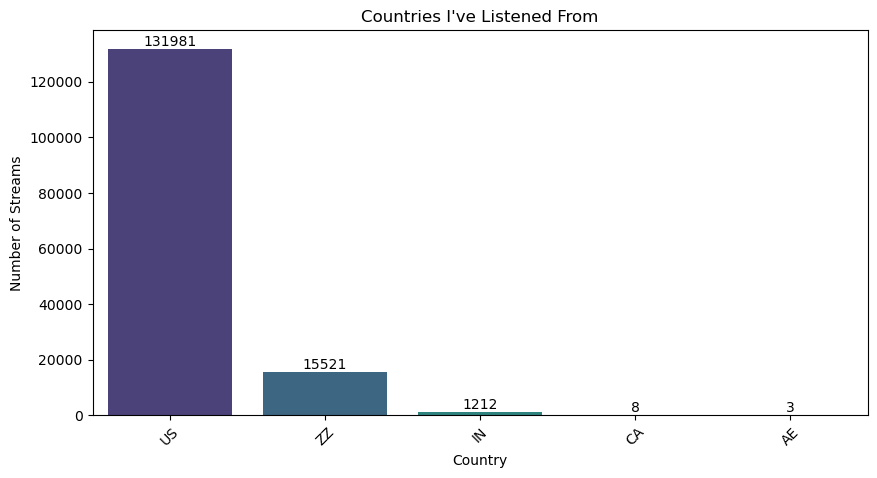

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(x=country_counts.index, y=country_counts.values, palette="viridis", hue=country_counts.index)
plt.xlabel("Country")
plt.ylabel("Number of Streams")
plt.title("Countries I've Listened From")
plt.xticks(rotation=45)

for index, value in enumerate(country_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()


**TOP 10 2024 Artists**

In [18]:
df[df['year']==2024].groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].count().sort_values(ascending=False)

master_metadata_album_artist_name
Snow Strippers       1297
Charli xcx            983
MGNA Crrrta           828
Grimes                627
Caroline Polachek     597
                     ... 
Melanie Martinez        1
Merely                  1
$werve                  1
鬼堯                      1
funeral                 1
Name: master_metadata_album_artist_name, Length: 2042, dtype: int64

In [19]:
artists_2024 = df[df['year']==2024].groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].count().sort_values(ascending=False)
top10_artists_2024 = artists_2024.head(10)

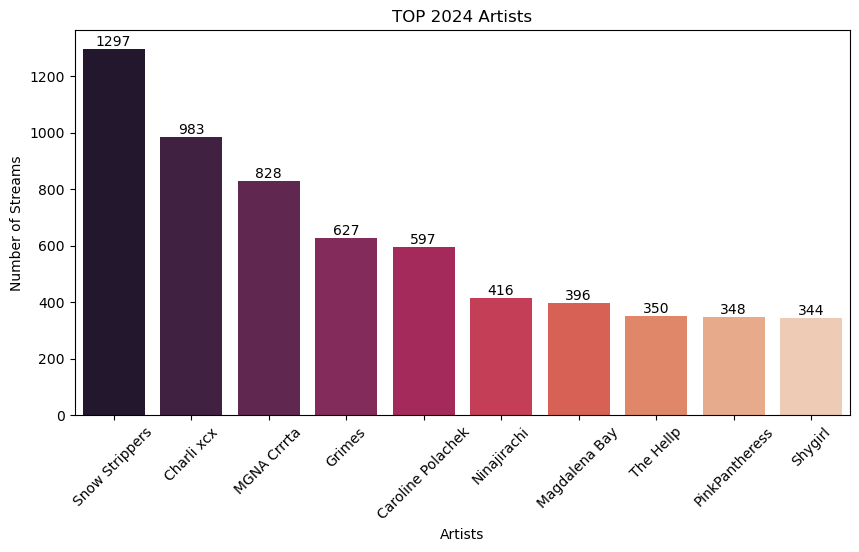

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(x=top10_artists_2024.index, y=top10_artists_2024.values, palette="rocket", hue=top10_artists_2024.index)
plt.xlabel("Artists")
plt.ylabel("Number of Streams")
plt.title("TOP 2024 Artists")
plt.xticks(rotation=45)

for index, value in enumerate(top10_artists_2024.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()


**OFFLINE Column Investigation**

In [35]:
df[df['offline']==True].tail()

,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,spotify_episode_uri,reason_start,reason_end,shuffle,skipped,offline,incognito_mode,year
110249,2024-12-29 17:35:20-05:00,ios,166640,US,UP - KARINA Solo,aespa,SYNK : PARALLEL LINE - Special Digital Single,spotify:track:5sjnkOfTLCLNfkkchI2re2,None,None,None,trackdone,trackdone,True,False,True,False,2024
110250,2024-12-29 17:38:39-05:00,ios,198232,US,Fire in the belly,LE SSERAFIM,UNFORGIVEN,spotify:track:05RlBHEZg1RmL9DnPgv9Qq,None,None,None,trackdone,trackdone,True,False,True,False,2024
110251,2024-12-29 17:41:08-05:00,ios,148186,US,mute,Shygirl,Club Shy,spotify:track:3jxxGBDq5ePJE91R909Yae,None,None,None,trackdone,trackdone,True,False,True,False,2024
110252,2024-12-29 17:44:14-05:00,ios,186181,US,Your Teeth In My Neck,Kali Uchis,Isolation,spotify:track:54IbnYEdA3ymfxv07WgN3b,None,None,None,trackdone,trackdone,True,False,True,False,2024
110253,2024-12-29 17:45:46-05:00,ios,90181,US,Neverender - Kaytranada Remix,Justice,Neverender,spotify:track:1GFz4dKoSUt9aOBeLJFfJh,None,None,None,trackdone,endplay,True,True,True,False,2024


**Investigating Conn_Country Column**

Looking into unknown country "ZZ"

In [36]:
ermm = df[df['conn_country']=='ZZ']
ermm


,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,spotify_episode_uri,reason_start,reason_end,shuffle,skipped,offline,incognito_mode,year
66,2017-05-25 16:43:14-04:00,Partner spotify web_player,176586,ZZ,HUMBLE.,Kendrick Lamar,DAMN.,spotify:track:7KXjTSCq5nL1LoYtL7XAwS,None,None,None,clickrow,unknown,False,False,False,False,2017
67,2017-05-25 16:48:52-04:00,Partner spotify web_player,287944,ZZ,I'm the One,DJ Khaled,I'm the One,spotify:track:72Q0FQQo32KJloivv5xge2,None,None,None,clickrow,unknown,False,False,False,False,2017
68,2017-05-25 16:49:35-04:00,Partner spotify web_player,2947,ZZ,HUMBLE.,Kendrick Lamar,DAMN.,spotify:track:7KXjTSCq5nL1LoYtL7XAwS,None,None,None,clickrow,trackdone,False,False,False,False,2017
69,2017-05-25 16:52:43-04:00,Partner spotify web_player,185180,ZZ,DNA.,Kendrick Lamar,DAMN.,spotify:track:6HZILIRieu8S0iqY8kIKhj,None,None,None,clickrow,unknown,False,False,False,False,2017
70,2017-05-25 16:55:56-04:00,Partner spotify web_player,26460,ZZ,LOVE. FEAT. ZACARI.,Kendrick Lamar,DAMN.,spotify:track:6PGoSes0D9eUDeeAafB2As,None,None,None,unknown,trackdone,False,False,False,False,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31656,2020-08-17 22:01:48-04:00,web_player windows 10;chrome 84.0.4147.125;des...,67441,ZZ,Hello Kitty,Jazmin Bean,Worldwide Torture,spotify:track:5GCwCzJkdefEhYU6mLyRu1,None,None,None,remote,endplay,False,False,False,False,2020
31657,2020-08-17 22:02:55-04:00,web_player windows 10;chrome 84.0.4147.125;des...,42622,ZZ,Signs,Snoop Dogg,R&G (Rhythm & Gangsta): The Masterpiece,spotify:track:4HSAJpNocVNJbwbQvtCMdO,None,None,None,clickrow,endplay,False,False,False,False,2020
31658,2020-08-17 22:02:55-04:00,web_player windows 10;chrome 84.0.4147.125;des...,42622,ZZ,Signs,Snoop Dogg,R&G (Rhythm & Gangsta): The Masterpiece,spotify:track:4HSAJpNocVNJbwbQvtCMdO,None,None,None,clickrow,endplay,False,False,False,False,2020
31659,2020-08-17 22:08:33-04:00,web_player windows 10;chrome 84.0.4147.125;des...,285431,ZZ,Where's Your Head At,Basement Jaxx,Rooty,spotify:track:6cOyq898FB1fYOewPOwjyS,None,None,None,playbtn,trackdone,False,False,False,False,2020


Listening History in Canada

In [21]:
yerm = df[df['conn_country']=='CA']
yerm

,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,...,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,incognito_mode,year
77515,2023-02-10 18:03:03-05:00,windows,197415,CA,Turning Wheel,SPELLLING,The Turning Wheel,spotify:track:0mBpuZq2VrGiE2SCKRykV8,None,None,...,NaN,NaN,NaN,trackdone,endplay,True,True,False,False,2023
77516,2023-02-10 18:05:28-05:00,windows,144098,CA,SO HOT - THEBLACKLABEL REMIX BLACKPINK ARENA T...,BLACKPINK,"BLACKPINK ARENA TOUR 2018 ""SPECIAL FINAL IN KY...",spotify:track:1fMXWEkJpIH483OrKn1zFV,None,None,...,NaN,NaN,NaN,clickrow,trackdone,True,False,False,False,2023
77517,2023-02-10 18:05:32-05:00,windows,3658,CA,SOLO,JENNIE,SOLO,spotify:track:2wVDWtLKXunswWecARNILj,None,None,...,NaN,NaN,NaN,trackdone,endplay,True,True,False,False,2023
77518,2023-02-10 18:08:47-05:00,windows,193858,CA,Villain,PIXY,REBORN,spotify:track:5Doeu3aSa5tBHayCx0EbHa,None,None,...,NaN,NaN,NaN,clickrow,trackdone,True,False,False,False,2023
60731,2023-03-19 16:36:16-04:00,windows,57353,CA,Look,Red Velvet,Perfect Velvet - The 2nd Album,spotify:track:48Nd8rdc0WVG4rHTd76Mh6,None,None,...,NaN,NaN,NaN,trackdone,unexpected-exit,True,False,False,False,2023
65842,2023-11-18 17:37:47-05:00,windows,196757,CA,"Sex, Drugs, Etc.",Beach Weather,Chit Chat,spotify:track:7DbdUf8aHSYoliSjO6LZv6,None,None,...,NaN,NaN,NaN,trackdone,trackdone,True,False,False,False,2023
65843,2023-11-18 17:43:27-05:00,windows,333815,CA,Enter Sandman,Rina Sawayama,Enter Sandman,spotify:track:18sXLZIxb7nYy3g0Wnx8bA,None,None,...,NaN,NaN,NaN,trackdone,trackdone,True,False,False,False,2023
65870,2023-11-18 20:25:55-05:00,windows,1389,CA,She Wolf,Shakira,She Wolf (Expanded Edition),spotify:track:4cS2HQ6jK80vqdY9ofpztx,None,None,...,NaN,NaN,NaN,trackdone,unexpected-exit-while-paused,True,False,False,False,2023


**TOP 2024 Artists Extended?**

In [38]:
#artists_2024 = df[df['year']==2024].groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].count().sort_values(ascending=False)
top20_artists_2024 = artists_2024.head(25)

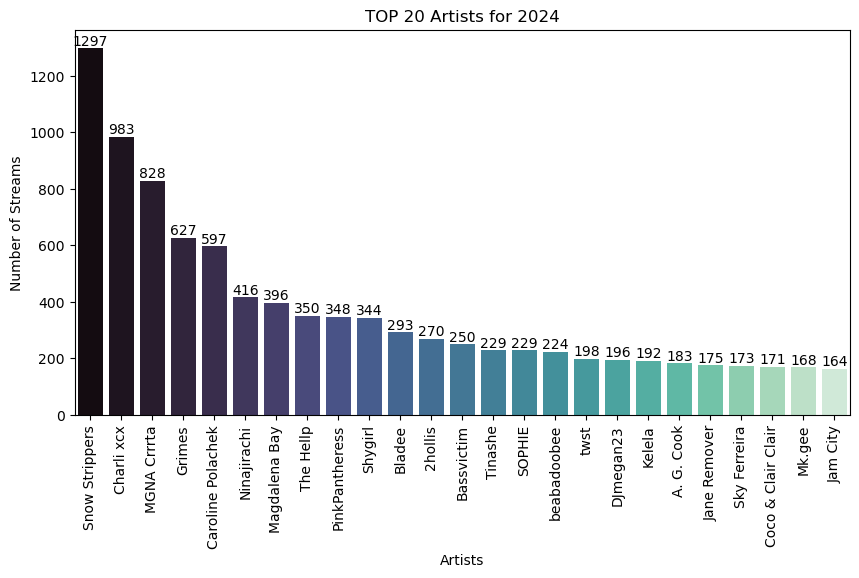

In [47]:
plt.figure(figsize=(10,5))
sns.barplot(x=top20_artists_2024.index, y=top20_artists_2024.values, palette="mako", hue = top20_artists_2024.index)
plt.xlabel("Artists")
plt.ylabel("Number of Streams")
plt.title("TOP 20 Artists for 2024")
plt.xticks(rotation=90)

for index, value in enumerate(top20_artists_2024.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()


**TOP SONGS OF 2024**

In [41]:
top_songs_2024 = df[df['year']==2024].groupby('master_metadata_track_name')['master_metadata_track_name'].count().sort_values(ascending=False)
top10_songs_2024 = top_songs_2024.head(10)

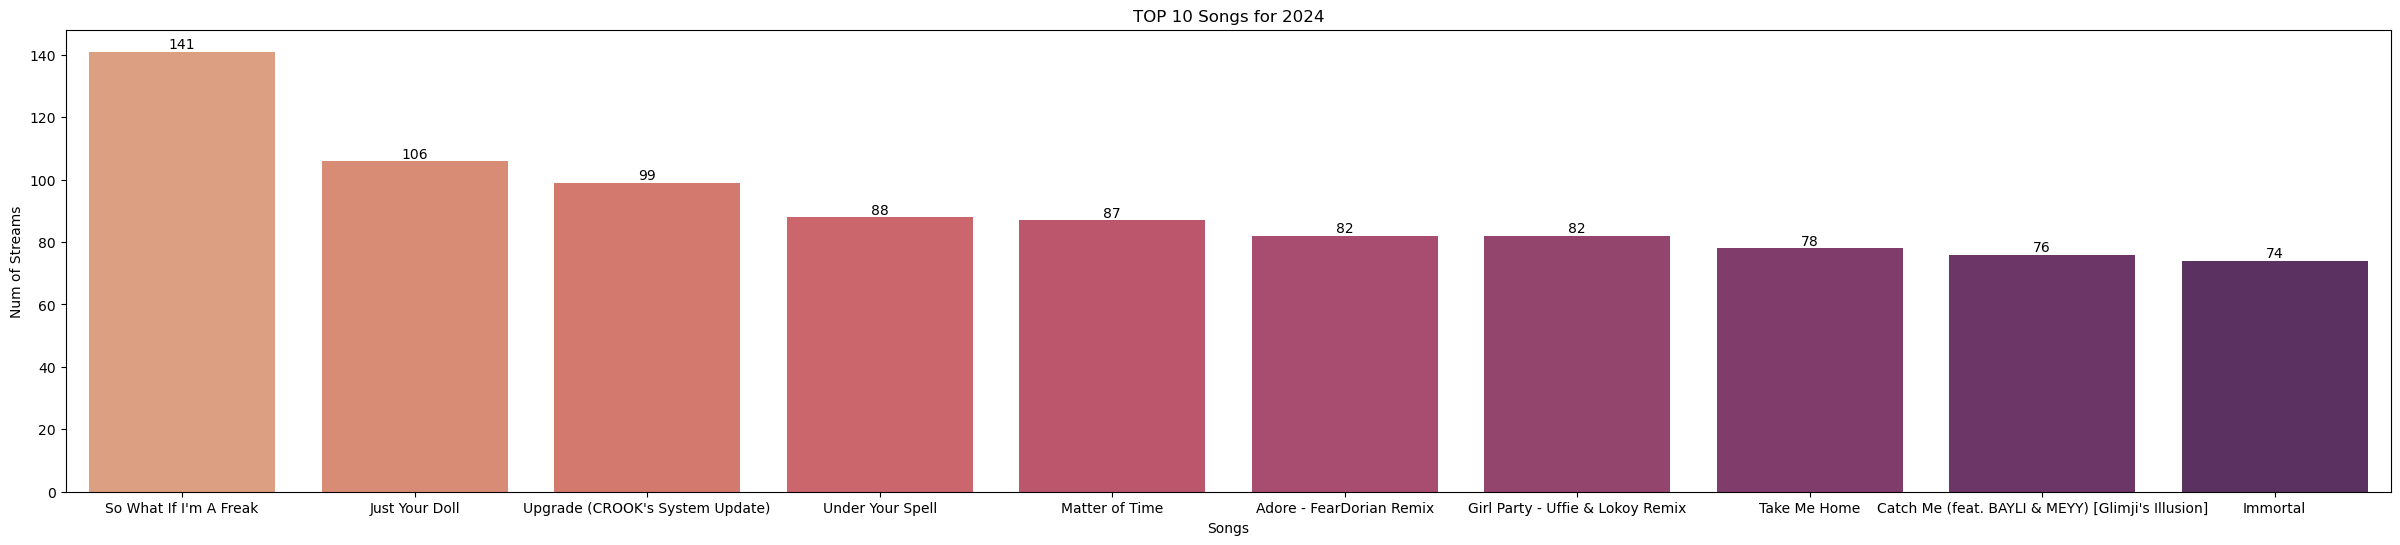

In [45]:
plt.figure(figsize=(30,6))
sns.barplot(x=top10_songs_2024.index, y=top10_songs_2024.values, hue=top10_songs_2024.index, palette="flare")
plt.xlabel("Songs")
plt.ylabel("Num of Streams")
plt.title("TOP 10 Songs for 2024")
plt.xticks(rotation=0)

for index, value in enumerate(top10_songs_2024.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()


**TOP SONGS OF 2025??**

In [22]:
top_songs_2025 = df[df['year']==2025].groupby('master_metadata_track_name')['master_metadata_track_name'].count().sort_values(ascending=False)
t10_25 = top_songs_2025.head(10)

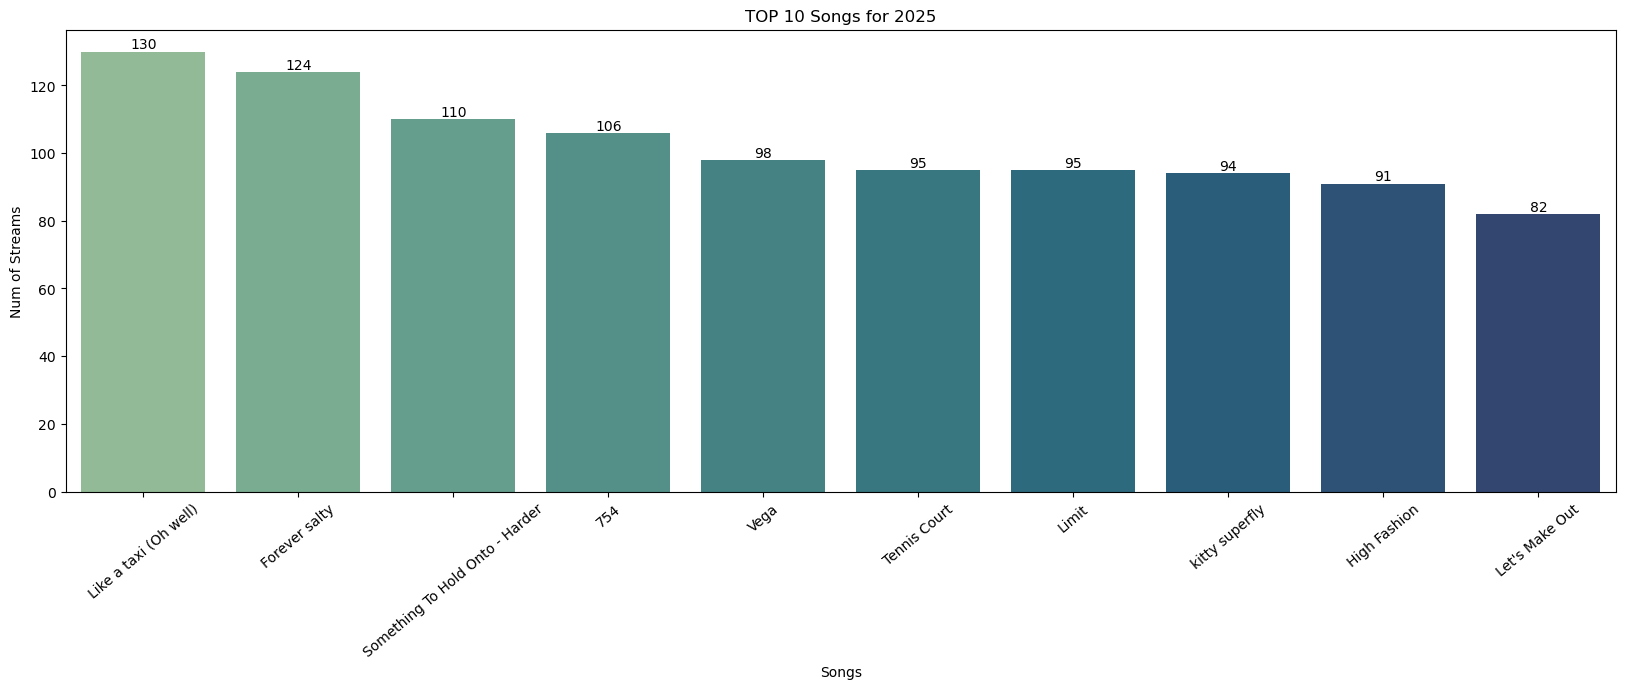

In [ ]:
plt.figure(figsize=(20,6))
sns.barplot(x=t10_25.index, y=t10_25.values, palette="crest", hue=t10_25.index)
plt.xlabel("Songs")
plt.ylabel("Num of Streams")
plt.title("TOP 10 Songs for 2025")
plt.xticks(rotation=40)

for index, value in enumerate(t10_25.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()


2025 artists

In [43]:
artists_2025 = df[df['year']==2025].groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].count().sort_values(ascending=False)
top20_artists_2025 = artists_2025.head(20)

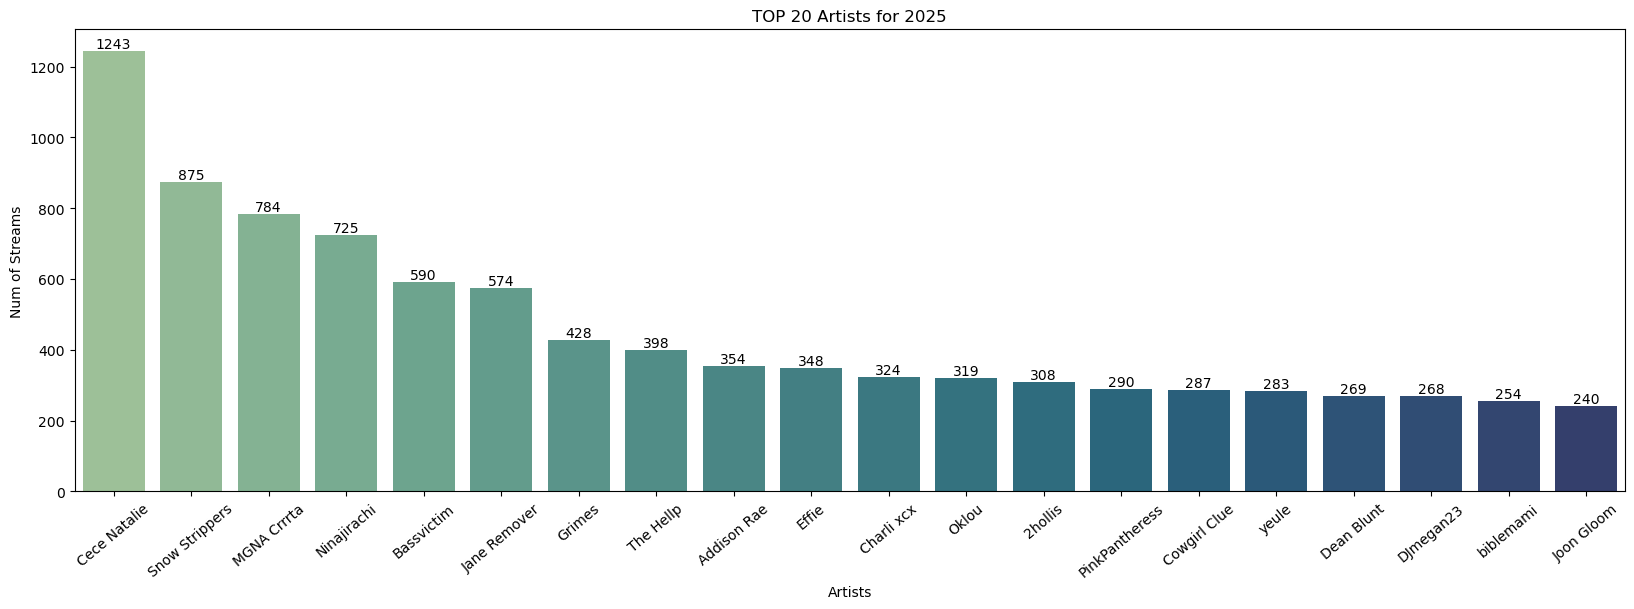

In [44]:
plt.figure(figsize=(20,6))
sns.barplot(x=top10_artists_2024.index, y=top10_artists_2024.values, palette="crest", hue=top10_artists_2024.index)
plt.xlabel("Artists")
plt.ylabel("Num of Streams")
plt.title("TOP 20 Artists for 2025")
plt.xticks(rotation=40)

for index, value in enumerate(top20_artists_2025.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()


2026 stuff

In [46]:
top_songs_2026 = df[df['year']==2026].groupby('master_metadata_track_name')['master_metadata_track_name'].count().sort_values(ascending=False)
top20_songs_2026 = top_songs_2026.head(20)

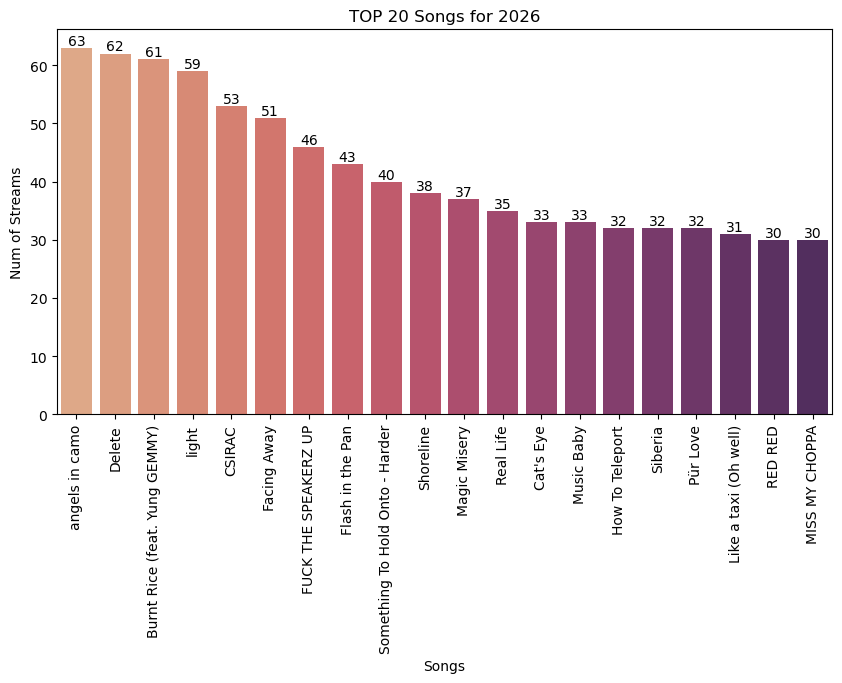

In [49]:
plt.figure(figsize=(10,5))
sns.barplot(x=top20_songs_2026.index, y=top20_songs_2026.values, hue=top20_songs_2026.index, palette="flare")
plt.xlabel("Songs")
plt.ylabel("Num of Streams")
plt.title("TOP 20 Songs for 2026")
plt.xticks(rotation=90)

for index, value in enumerate(top20_songs_2026.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()


In [39]:
artists_2026 = df[df['year']==2026].groupby('master_metadata_album_artist_name')['master_metadata_album_artist_name'].count().sort_values(ascending=False)
top20_artists_2026 = artists_2026.head(20)

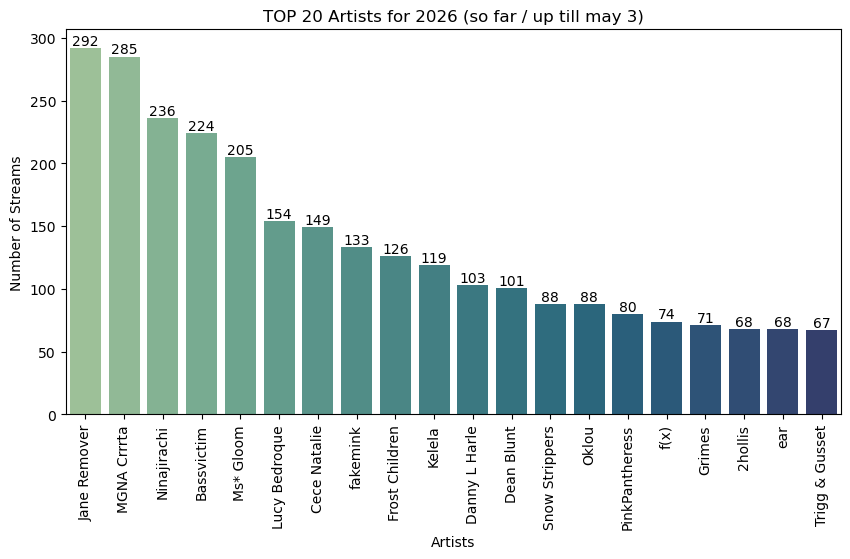

In [42]:
plt.figure(figsize=(10,5))
sns.barplot(x=top20_artists_2026.index, y=top20_artists_2026.values, palette="crest", hue = top20_artists_2026.index)
plt.xlabel("Artists")
plt.ylabel("Number of Streams")
plt.title("TOP 20 Artists for 2026 (so far / up till may 3)")
plt.xticks(rotation=90)

for index, value in enumerate(top20_artists_2026.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()


In [36]:
df.tail(5)

,ts,platform,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,...,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,incognito_mode,year
145594,2026-05-03 19:45:03-04:00,windows,164375,US,Daytona,slayr,Half Blood (BloodLuxe),spotify:track:1z8YIll8YL4H0HqWH6MRH8,NaN,NaN,...,NaN,NaN,NaN,trackdone,trackdone,True,False,False,False,2026
145595,2026-05-03 19:49:54-04:00,windows,296831,US,Doom Bikini,james K,Friend,spotify:track:0wl8hkUc39H3WwNyKWApMT,NaN,NaN,...,NaN,NaN,NaN,trackdone,trackdone,True,False,False,False,2026
145596,2026-05-03 19:52:12-04:00,windows,144601,US,Blonde,OsamaSon,Flex Musix,spotify:track:4N7HxVSOdRKlPbSWzghIyN,NaN,NaN,...,NaN,NaN,NaN,trackdone,trackdone,True,False,False,False,2026
145597,2026-05-03 19:54:41-04:00,windows,155000,US,CONTROL,Frost Children,SISTER,spotify:track:1gfgqrlGzSWP60eivYn702,NaN,NaN,...,NaN,NaN,NaN,trackdone,trackdone,True,False,False,False,2026
145598,2026-05-03 19:59:09-04:00,windows,273285,US,How To Teleport,Jane Remover,♡,spotify:track:5BUTPG0Csnl1fF5RFg5lUH,NaN,NaN,...,NaN,NaN,NaN,trackdone,trackdone,True,False,False,False,2026


most skipped songs of 2026

In [53]:
skipped_songs_2026 = df[(df['year']==2026) & (df['skipped'] == True)].groupby('master_metadata_track_name')['master_metadata_track_name'].count().sort_values(ascending=False)
top20_skipped_songs_2026 = skipped_songs_2026.head(20)

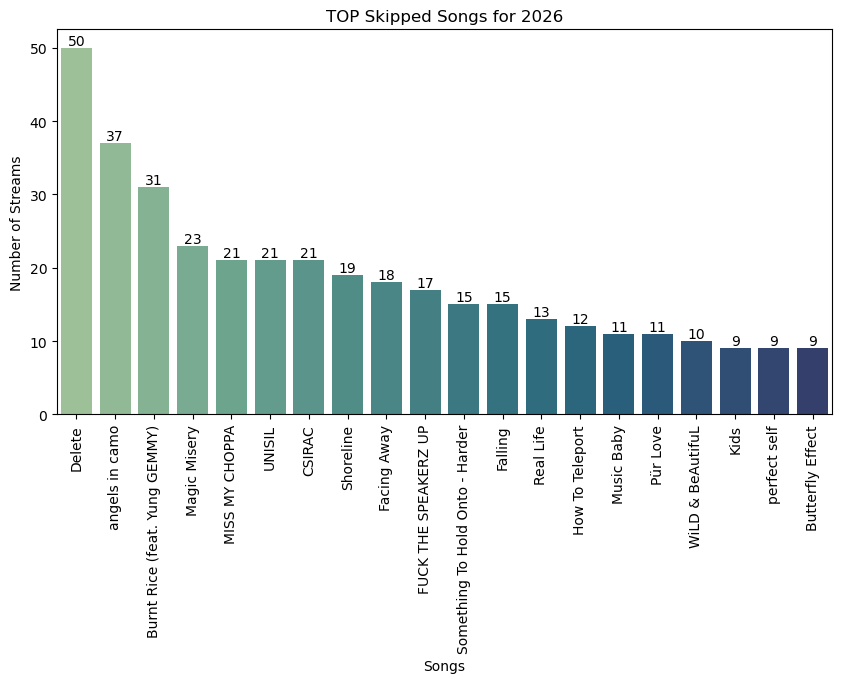

In [54]:
plt.figure(figsize=(10,5))
sns.barplot(x=top20_skipped_songs_2026.index, y=top20_skipped_songs_2026.values, palette="crest", hue = top20_skipped_songs_2026.index)
plt.xlabel("Songs")
plt.ylabel("Number of Streams")
plt.title("TOP Skipped Songs for 2026")
plt.xticks(rotation=90)

for index, value in enumerate(top20_skipped_songs_2026.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.show()
